# ISyE 6740 Project

## DIM RED METHODS

In [1]:
import time
import random
import h5py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # the tidy way

In [2]:
from platform import python_version
print(python_version())

3.11.4


## 1. Read PCam data

read from h5 files

In [3]:
PATH = './db/'
data = dict()
for s in ['train_x', 'train_y', 'test_x', 'test_y']:
    file = 'camelyonpatch_level_2_split_' + s + '.h5'
    data[s] = h5py.File(PATH + file + '/' +  file, "r")

In [4]:
for s in ['train_x', 'train_y', 'test_x', 'test_y']:
    for k in data[s].keys():
        print(s, k)
        dset = data[s][k]
        display(dset.shape)

train_x x


(262144, 96, 96, 3)

train_y y


(262144, 1, 1, 1)

test_x x


(32768, 96, 96, 3)

test_y y


(32768, 1, 1, 1)

## 2. Create downsamples and convert images to grayscale

Create downsamples and convert images to grayscale

In [28]:
len(data['train_x']['x'])

262144

In [29]:
ntrain = 5000
ntest =  5000
train_idx = np.sort(np.random.choice(len(data['train_x']['x']), size=ntrain,replace=False))
test_idx = np.sort(np.random.choice(len(data['test_x']['x']), size=ntest,replace=False))
X_train_0 = data['train_x']['x'][train_idx]
X_test_0  = data['test_x']['x'][test_idx]
y_train = np.array(data['train_y']['y'][train_idx]).ravel()
y_test  = np.array(data['test_y']['y'][test_idx]).ravel()
X_train_0.shape, y_train.shape, X_test_0.shape, y_test.shape

((5000, 96, 96, 3), (5000,), (5000, 96, 96, 3), (5000,))

train images to grayscale

In [30]:
X_train_g = np.ones([ntrain, 96, 96]) * np.inf
X_test_g  = np.ones([ntest,  96, 96]) * np.inf
X_train_g.shape, X_test_g.shape, X_train_g[10,:2,:2]

((5000, 96, 96),
 (5000, 96, 96),
 array([[inf, inf],
        [inf, inf]]))

In [31]:
wt = np.transpose(np.array([0.2989, 0.5870, 0.1140]))
for n in range(ntrain):
    for i in range(96):
        for j in range(96):
            X_train_g[n][i,j] = wt @ X_train_0[n][i,j] / 255
X_train_g.shape

(5000, 96, 96)

In [32]:
# plt.imshow(X_train_0[0]); plt.title('original RGB', fontsize = 15); plt.show()
# plt.imshow(X_train_g[0], cmap=plt.get_cmap('binary')); plt.title('Grayscale', fontsize = 15); plt.show()
# X_train_0[10].shape, X_train_g[10].shape, X_train_0[10][:2,:2], X_train_g[10][:2,:2]

In [33]:
wt = np.transpose(np.array([0.2989, 0.5870, 0.1140]))
for n in range(ntest):
    for i in range(96):
        for j in range(96):
            X_test_g[n][i,j] = wt @ X_test_0[n][i,j] / 255
X_test_g.shape

(5000, 96, 96)

In [34]:
# plt.imshow(X_test_0[10]); plt.show()
# plt.imshow(X_test_g[10], cmap=plt.get_cmap('binary')); plt.show()
# X_test_0[10].shape, X_test_g[10].shape, X_test_0[10][:2,:2], X_test_g[10][:2,:2]

In [35]:
# rgb_splitter(X_test_0[10], X_test_g[10])

Extract 32 x 32 center

In [36]:
X_train = np.ones([ntrain, 32*32]) * np.inf
X_test  = np.ones([ntest,  32*32]) * np.inf
X_train.shape, X_test.shape

((5000, 1024), (5000, 1024))

In [37]:
for i in range(ntrain):
    X_train[i] = X_train_g[i][32:(32*2),32:(32*2)].ravel()
for j in range(ntest):
    X_test[j] = X_test_g[j][32:(32*2),32:(32*2)].ravel()

In [38]:
print('X_train: ', type(X_train), X_train.shape)
print('y_train: ', type(y_train), y_train.shape, y_train[:5])
print('X_test: ', type(X_test), X_test.shape)
print('y_test: ', type(y_test), y_test.shape, y_test[:5])

X_train:  <class 'numpy.ndarray'> (5000, 1024)
y_train:  <class 'numpy.ndarray'> (5000,) [0 1 0 1 0]
X_test:  <class 'numpy.ndarray'> (5000, 1024)
y_test:  <class 'numpy.ndarray'> (5000,) [0 1 1 1 0]


In [39]:
np.sum(np.isinf(X_train)), np.sum(np.isinf(X_test))

(0, 0)

Display a few images

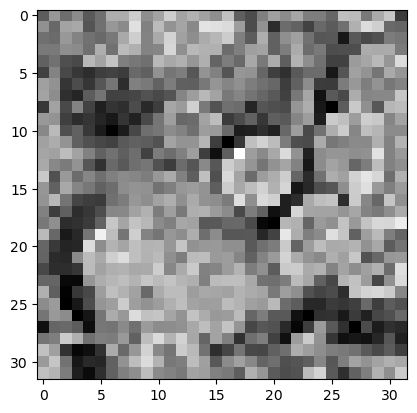

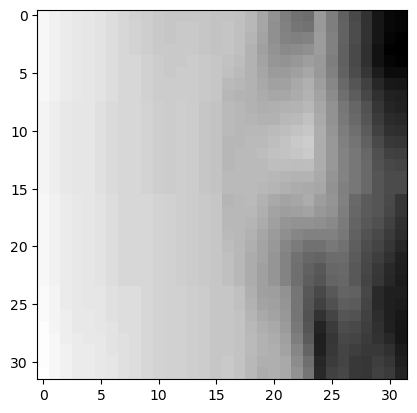

In [40]:
for i in np.random.choice(ntrain, 2, replace = False):
    plt.imshow(X_train[i].reshape([32,32]), cmap=plt.get_cmap('binary'))
    plt.show()

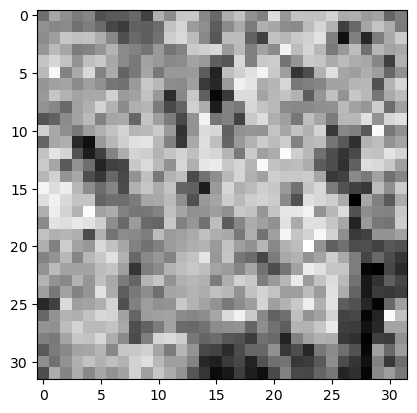

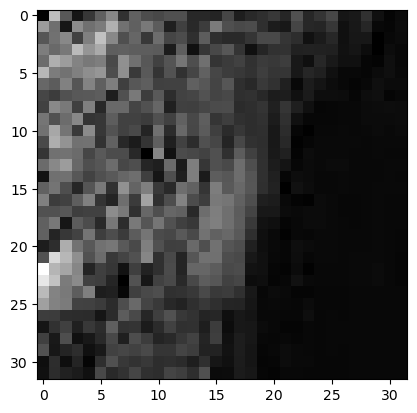

In [41]:
for i in np.random.choice(ntest, 2, replace = False):
    plt.imshow(X_test[i].reshape([32,32]), cmap=plt.get_cmap('binary'))
    plt.show()

###  3. DIM RED PROCEDURE

In [166]:
import numpy as np
from matplotlib import offsetbox
from sklearn.preprocessing import MinMaxScaler

def plot_embedding(X, y, title):
    _, ax = plt.subplots()
    X = MinMaxScaler().fit_transform(X)

    for digit in y:
        ax.scatter(
            *X[y == digit].T,
            marker='.',
            s=20,
            color=plt.cm.Set1(digit),
            alpha=0.91,
            zorder=2 )
    shown_images = np.array([[1.0, 1.0]])  # just something big
    for i in range(X.shape[0]):
        # plot every digit on the embedding
        # show an annotation box for a group of digits
        dist = np.sum((X[i] - shown_images) ** 2, 1)
        if np.min(dist) < 4e-3:
            # don't show points that are too close
            continue
        shown_images = np.concatenate([shown_images, [X[i]]], axis=0)
    ax.set_title(title)
    ax.axis("off")

In [292]:
from sklearn.manifold import (
    MDS,
    TSNE,
    Isomap,
    LocallyLinearEmbedding,
    SpectralEmbedding,
)
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.random_projection import SparseRandomProjection

n_neighbors = 5
n_comp = 500

embeddings = {
    "Isomap embedding": Isomap(n_neighbors=5, n_components=n_comp)}

In [293]:
projections, timing = {}, {}
for name, transformer in embeddings.items():
    print(f"Computing {name}...")
    start_time = time.time()
    PX_train = transformer.fit_transform(X_train, y_train)
    timing[name] = time.time() - start_time
for name, transformer in embeddings.items():
    print(f"Computing {name}...")
    start_time = time.time()
    PX_test = transformer.fit_transform(X_test, y_test)
    timing[name] = time.time() - start_time

Computing Isomap embedding...
Computing Isomap embedding...


C:\Users\a_lar\anaconda3\Lib\site-packages\sklearn\manifold\_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\a_lar\anaconda3\Lib\site-packages\scipy\sparse\_index.py:103: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


In [294]:
# for name in timing:
#     title = f"{name}"
#     plot_embedding(projections[name], y_train, title)
# plt.show()

### Fit KNN KSVM to ISOMAP projections

In [295]:
PX_train.shape, PX_test.shape, y_train.shape, y_test.shape

((5000, 500), (5000, 500), (5000,), (5000,))

In [296]:
import warnings
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.svm import NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.ensemble import AdaBoostClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support

In [297]:
def get_metrics(predicted_y, test_y):
    d = {}
    acc, bal_acc = accuracy_score(test_y,predicted_y), balanced_accuracy_score(test_y,predicted_y)
    precision, recall, F1_score, support = precision_recall_fscore_support(test_y, predicted_y, average=None)
    d['confusion'] = confusion_matrix(test_y, predicted_y)
    d['accuracy'] = acc
    d['balanced_accuracy'] = bal_acc
    d['precision'] = precision
    d['recall'] = recall
    d['F1_score'] = F1_score
    d['support'] = support
    return d

#### FIND BEST PARAMS WITH SEARCHES

In [298]:
import scipy.stats as stats
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [299]:
# Utility function to report best scores
def report(results, n_top=3):
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results["rank_test_score"] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print(
                "Mean validation score: {0:.3f} (std: {1:.3f})".format(
                    results["mean_test_score"][candidate],
                    results["std_test_score"][candidate],
                )
            )
            print("Parameters: {0}".format(results["params"][candidate]))
            print("")

In [300]:
# get some data
X, y = PX_train.copy(), y_train.copy()

# build a classifier
clf = KNeighborsClassifier()
# specify parameters and distributions to sample from AND # run randomized search
param_dist = {"n_neighbors": stats.randint(3, 20)}
n_iter_search = 5
random_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=n_iter_search)
start = time.time()
random_search.fit(X, y)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
    % (( time.time() - start), n_iter_search))
report(random_search.cv_results_)

# use a full grid over all parameters AND # run grid search
param_grid = {
   "n_neighbors": [4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]}
grid_search = GridSearchCV(clf, param_grid=param_grid)
start = time.time()
grid_search.fit(X, y)
print(
    "GridSearchCV took %.2f seconds for %d candidate parameter settings."
    % ( time.time() - start, len(grid_search.cv_results_["params"])))
report(grid_search.cv_results_)

RandomizedSearchCV took 1.36 seconds for 5 candidates parameter settings.
Model with rank: 1
Mean validation score: 0.662 (std: 0.009)
Parameters: {'n_neighbors': 12}

Model with rank: 2
Mean validation score: 0.659 (std: 0.010)
Parameters: {'n_neighbors': 13}

Model with rank: 3
Mean validation score: 0.659 (std: 0.005)
Parameters: {'n_neighbors': 15}

GridSearchCV took 4.57 seconds for 17 candidate parameter settings.
Model with rank: 1
Mean validation score: 0.664 (std: 0.006)
Parameters: {'n_neighbors': 14}

Model with rank: 2
Mean validation score: 0.662 (std: 0.009)
Parameters: {'n_neighbors': 12}

Model with rank: 3
Mean validation score: 0.662 (std: 0.007)
Parameters: {'n_neighbors': 16}



In [301]:
# get some data
X, y = PX_train.copy(), y_train.copy()

# build a classifier
clf = svm.SVC(kernel='rbf',random_state = random_state)
# specify parameters and distributions to sample from AND # run randomized search
param_dist = {"gamma": stats.uniform(0,2),
              "C":stats.randint(1,10) }

n_iter_search = 10
random_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=n_iter_search)
start = time.time()
random_search.fit(X, y)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
    % ((time.time() - start), n_iter_search))
report(random_search.cv_results_)

# use a full grid over all parameters AND # run grid search
param_grid = {"gamma": [0.1, 0.25, 0.5,0.75,1,1.5],
              "C":[2,3,5,8,10]}
grid_search = GridSearchCV(clf, param_grid=param_grid)
start = time.time()
grid_search.fit(X, y)
print(
    "GridSearchCV took %.2f seconds for %d candidate parameter settings."
    % (time.time() - start, len(grid_search.cv_results_["params"])))
report(grid_search.cv_results_)

RandomizedSearchCV took 112.91 seconds for 10 candidates parameter settings.
Model with rank: 1
Mean validation score: 0.657 (std: 0.006)
Parameters: {'C': 2, 'gamma': 0.07389693855829216}

Model with rank: 2
Mean validation score: 0.631 (std: 0.009)
Parameters: {'C': 4, 'gamma': 0.16251032425669054}

Model with rank: 3
Mean validation score: 0.621 (std: 0.012)
Parameters: {'C': 8, 'gamma': 0.23937999713783276}

GridSearchCV took 328.56 seconds for 30 candidate parameter settings.
Model with rank: 1
Mean validation score: 0.651 (std: 0.010)
Parameters: {'C': 2, 'gamma': 0.1}

Model with rank: 2
Mean validation score: 0.649 (std: 0.007)
Parameters: {'C': 3, 'gamma': 0.1}

Model with rank: 3
Mean validation score: 0.646 (std: 0.006)
Parameters: {'C': 5, 'gamma': 0.1}



In [358]:
k = 11  # KNN
C, gamma = 1, 0.1  # SVM regularization parameter
random_state = 701

In [359]:
keys = ['KNN', 'KSVM']
pretty_keys = ['KNN', 'KSVM']
clfs = [KNeighborsClassifier(n_neighbors = k), 
        svm.SVC(kernel='rbf',
                gamma=gamma, 
                C=C, 
                random_state = random_state)]

Fit classifiers to projections within a loop:

In [360]:
TIC0, TIC = time.time(), time.time() 
metrics = {}
for clf, key in zip(clfs, keys):
    fitted = clf.fit(PX_train, y_train)
    TOC = time.time()
    print('\n', key, 'finished in %f seconds \n' % float((TOC - TIC)/1))        
    TIC = TOC
    metrics[key] = get_metrics(fitted.predict(PX_test), y_test) 
    
TOC = time.time()
print('Total elapsed time: %f minutes \n' % float((TOC - TIC0)/60))


 KNN finished in 0.009028 seconds 


 KSVM finished in 2.884881 seconds 

Total elapsed time: 0.114273 minutes 



Report Confusion Marices

In [361]:
print('\n', '-'*25, ' CONFUSION MATRICES ', '-'*25)
for key, pkey in zip(keys, pretty_keys):
    df = pd.DataFrame(metrics[key]['confusion'])
    filename = key+'.csv'
    df.to_csv(filename)
    print('\n', pkey, ':')
    display(df)


 -------------------------  CONFUSION MATRICES  -------------------------

 KNN :


,0,1
0,1463,1069
1,756,1712



 KSVM :


,0,1
0,19,2513
1,18,2450


In [362]:
# def rgb_splitter(image, image_g):
#     rgb_list = ['Reds','Greens','Blues']
#     fig, ax = plt.subplots(1, 5, figsize=(15,5), sharey = True)
#     ax[0].imshow(image); ax[0].set_title('Original', fontsize = 15)
#     ax[1].imshow(image_g,cmap=plt.get_cmap('binary') ); ax[1].set_title('Grayscale', fontsize = 15)
#     for i in range(3):
#         ax[i+2].imshow(image[:,:,i], cmap = rgb_list[i])
#         ax[i+2].set_title(rgb_list[i], fontsize = 15)

In [363]:
# red_girl = X_train_0[10].copy()
# red_filtered = (red_girl[:,:,0] > 100) & (red_girl[:,:,1] < 100) & (red_girl[:,:,2] < 110)
# plt.figure(num=None, figsize=(8, 6), dpi=80)
# red_girl_new = red_girl.copy()
# red_girl_new[:, :, 0] = red_girl_new[:, :, 0] * red_filtered
# red_girl_new[:, :, 1] = red_girl_new[:, :, 1] * red_filtered
# red_girl_new[:, :, 2] = red_girl_new[:, :, 2] * red_filtered
# plt.imshow(red_girl_new)

In [364]:
# plt.imshow(X_train_0[0])